In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# B. Data Loading and Preprocessing

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer, StopWordsRemover

# 1. Start Spark session
spark = SparkSession.builder.appName("TrendyWearSentiment").getOrCreate()

# 2. Load data
data = spark.read.csv("/content/drive/MyDrive/sample30.csv", header=True, inferSchema=True)

# 3. Check schema to confirm all columns
data.printSchema()

# 4. Tokenize the review text column: reviews_text
tokenizer = Tokenizer(inputCol="reviews_text", outputCol="words")
data_words = tokenizer.transform(data)

# 5. Remove stop words from tokenized words
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
data_clean = remover.transform(data_words)

# Show sample of processed words
data_clean.select("reviews_text", "filtered_words", "user_sentiment").show(5, truncate=False)


root
 |-- id: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- name: string (nullable = true)
 |-- reviews_date: string (nullable = true)
 |-- reviews_didPurchase: boolean (nullable = true)
 |-- reviews_doRecommend: boolean (nullable = true)
 |-- reviews_rating: integer (nullable = true)
 |-- reviews_text: string (nullable = true)
 |-- reviews_title: string (nullable = true)
 |-- reviews_userCity: string (nullable = true)
 |-- reviews_userProvince: string (nullable = true)
 |-- reviews_username: string (nullable = true)
 |-- user_sentiment: string (nullable = true)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Feature Extraction using TF-IDF

In [ ]:
from pyspark.ml.feature import HashingTF, IDF

# 6. Convert words to term frequency vector
hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=10000)
featurizedData = hashingTF.transform(data_clean)

# 7. Compute TF-IDF scores to scale features
idf = IDF(inputCol="rawFeatures", outputCol="features")
idfModel = idf.fit(featurizedData)
rescaledData = idfModel.transform(featurizedData)

# Check results
rescaledData.select("reviews_text", "features").show(5, truncate=False)


+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Next Step (D from earlier) — Sentiment Label Indexing
Since your label column is "user_sentiment", we will:


In [ ]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="user_sentiment", outputCol="label")
data_ready = indexer.fit(rescaledData).transform(rescaledData)

data_ready.select("user_sentiment", "label").show(25)


+--------------+-----+
|user_sentiment|label|
+--------------+-----+
|      Positive|  0.0|
|      Positive|  0.0|
|      Positive|  0.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Positive|  0.0|
|      Negative|  1.0|
|      Positive|  0.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Positive|  0.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Negative|  1.0|
|      Positive|  0.0|
|      Negative|  1.0|
|      Positive|  0.0|
|      Positive|  0.0|
|      Positive|  0.0|
|      Positive|  0.0|
|      Positive|  0.0|
+--------------+-----+
only showing top 25 rows



In [ ]:
from pyspark.sql import SparkSession

# Create Spark Session
spark = SparkSession.builder.appName("TrendyWear_Word2Vec_Sentiment").getOrCreate()

# Load the dataset (update path if using Colab/other env)
data = spark.read.csv("/content/drive/MyDrive/sample30.csv", header=True, inferSchema=True)

# Peek at the schema
data.printSchema()

# Show first few rows
data.show(5, truncate=False)


root
 |-- id: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- name: string (nullable = true)
 |-- reviews_date: string (nullable = true)
 |-- reviews_didPurchase: boolean (nullable = true)
 |-- reviews_doRecommend: boolean (nullable = true)
 |-- reviews_rating: integer (nullable = true)
 |-- reviews_text: string (nullable = true)
 |-- reviews_title: string (nullable = true)
 |-- reviews_userCity: string (nullable = true)
 |-- reviews_userProvince: string (nullable = true)
 |-- reviews_username: string (nullable = true)
 |-- user_sentiment: string (nullable = true)

+--------------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------+------------------------------------------+------------------------+-------------------+---

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover

# Tokenize text into words
tokenizer = Tokenizer(inputCol="reviews_text", outputCol="words")
data_words = tokenizer.transform(data)

# Remove stop words
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
data_clean = remover.transform(data_words)

# Show cleaned tokenized data
data_clean.select("reviews_text", "filtered_words", "user_sentiment").show(10, truncate=False)


+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Cell 3 — Word2Vec Feature Extraction

In [ ]:
from pyspark.ml.feature import Word2Vec

# Word2Vec transforms filtered words into dense vectors
word2Vec = Word2Vec(
    vectorSize=100,        # dimensionality of embeddings
    minCount=1,
    inputCol="filtered_words",
    outputCol="features"
)

word2Vec_model = word2Vec.fit(data_clean)
data_vec = word2Vec_model.transform(data_clean)
data_vec.select("filtered_words", "features").show(5, truncate=False)


+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
null_count = data.filter(data['user_sentiment'].isNull()).count()
print(f"Number of rows with NULL user_sentiment: {null_count}")


Number of rows with NULL user_sentiment: 37


In [ ]:
from pyspark.ml.feature import StringIndexer

# Filter data to include only "Positive" and "Negative" sentiments
filtered_data = data_vec.filter(data_vec["user_sentiment"].isin("Positive", "Negative"))

# Create StringIndexer with handleInvalid set to 'skip' or 'keep'
indexer = StringIndexer(inputCol="user_sentiment", outputCol="label", handleInvalid="skip")

# Fit and transform data
data_ready = indexer.fit(filtered_data).transform(filtered_data)

# Show label mapping after handling nulls
data_ready.select("user_sentiment", "label").distinct().show()

+--------------+-----+
|user_sentiment|label|
+--------------+-----+
|      Positive|  0.0|
|      Negative|  1.0|
+--------------+-----+



In [ ]:
# Split dataset into training and testing sets
train, test = data_ready.randomSplit([0.8, 0.2], seed=42)

print(f"Training Data Count: {train.count()}")
print(f"Testing Data Count: {test.count()}")


Training Data Count: 24003
Testing Data Count: 5875


 Logistic Regression on Word2Vec Features
#

In [ ]:
from pyspark.ml.classification import LogisticRegression

# L1/L2 regularization can be set via elasticNetParam
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)

# Train model
lr_model = lr.fit(train)

# Make predictions on test data
predictions = lr_model.transform(test)

# Show some predictions
predictions.select("reviews_text", "user_sentiment", "prediction", "probability").show(10, truncate=False)


+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+----------+------------------------------------------+
|reviews_text                                                                                                                                                                                                                                                                                                                                                                        |user_sentiment|prediction|probability                               |
+---------------------------------------------------------------------------------------------------------------

In [ ]:
predictions.select("rawPrediction", "probability", "prediction").show(5, truncate=False)


+----------------------------------------+------------------------------------------+----------+
|rawPrediction                           |probability                               |prediction|
+----------------------------------------+------------------------------------------+----------+
|[3.751899751341917,-3.751899751341917]  |[0.9770652397607353,0.022934760239264662] |0.0       |
|[6.063738426517714,-6.063738426517714]  |[0.9976797060911524,0.0023202939088475816]|0.0       |
|[4.952739374227267,-4.952739374227267]  |[0.9929855191383871,0.007014480861612937] |0.0       |
|[1.5262258355768143,-1.5262258355768143]|[0.821453437662014,0.17854656233798605]   |0.0       |
|[0.5691298244102618,-0.5691298244102618]|[0.6385623624376349,0.36143763756236513]  |0.0       |
+----------------------------------------+------------------------------------------+----------+
only showing top 5 rows



In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BinaryClassification").getOrCreate()

# Replace 'your_data.csv' with your file path
df = spark.read.csv("/content/drive/MyDrive/sample30.csv", header=True, inferSchema=True)

# View the schema to confirm columns and types
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- name: string (nullable = true)
 |-- reviews_date: string (nullable = true)
 |-- reviews_didPurchase: boolean (nullable = true)
 |-- reviews_doRecommend: boolean (nullable = true)
 |-- reviews_rating: integer (nullable = true)
 |-- reviews_text: string (nullable = true)
 |-- reviews_title: string (nullable = true)
 |-- reviews_userCity: string (nullable = true)
 |-- reviews_userProvince: string (nullable = true)
 |-- reviews_username: string (nullable = true)
 |-- user_sentiment: string (nullable = true)



In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Use the rawPrediction column which contains raw scores
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")

auc = evaluator.evaluate(predictions)

print(f"Model AUC: {auc:.4f}")

Model AUC: 0.8556


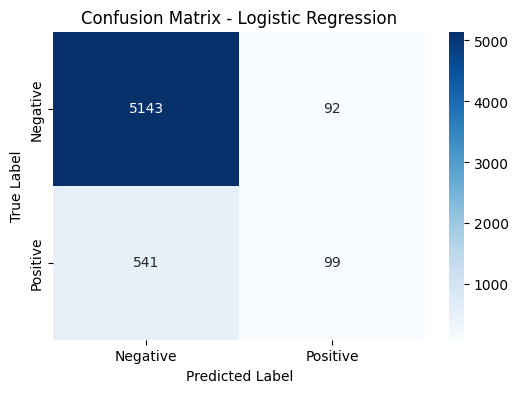

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert Spark predictions DataFrame to Pandas DataFrame for scikit-learn
predictions_pd = predictions.select("label", "prediction").toPandas()

# Calculate the confusion matrix
cm_lr = confusion_matrix(predictions_pd['label'], predictions_pd['prediction'])

# Display the confusion matrix using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

using the neural networks
**bold text**

In [ ]:
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/sample30.csv")

# Show first rows
df.head()


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


**preprocess**

In [ ]:
# Fill missing values
df['reviews_text'] = df['reviews_text'].fillna('')
df['user_sentiment'] = df['user_sentiment'].fillna('Neutral')

# Target variable: Positive = 1, Negative/Neutral = 0
df['target'] = df['user_sentiment'].map({'Positive':1, 'Negative':0, 'Neutral':0})

# Convert categorical features into numeric
df['didPurchase'] = df['reviews_didPurchase'].map({'Y':1, 'N':0})
df['doRecommend'] = df['reviews_doRecommend'].map({'Y':1, 'N':0})
df['brand_freq'] = df['brand'].map(df['brand'].value_counts())
df['categories_freq'] = df['categories'].map(df['categories'].value_counts())

# Select features
features = ['reviews_rating','didPurchase','doRecommend','brand_freq','categories_freq']
X = df[features].fillna(0).values
y = df['target'].values.reshape(-1,1)

# Train/Test Split
np.random.seed(42)
idx = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
X_train, X_test = X[idx[:train_size]], X[idx[train_size:]]
y_train, y_test = y[idx[:train_size]], y[idx[train_size:]]

# Normalize features
X_train = (X_train - X_train.mean(axis=0)) / (X_train.std(axis=0)+1e-8)
X_test  = (X_test  - X_test.mean(axis=0))  / (X_test.std(axis=0)+1e-8)


In [ ]:
# Activation functions
def sigmoid(z):
    return 1/(1+np.exp(-z))

def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z > 0).astype(float)

# Initialize weights
def initialize_params(input_dim, hidden_dim):
    np.random.seed(1)
    W1 = np.random.randn(input_dim, hidden_dim) * 0.01
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, 1) * 0.01
    b2 = np.zeros((1,1))
    return W1,b1,W2,b2

# Forward pass
def forward(X, W1,b1,W2,b2):
    Z1 = np.dot(X,W1)+b1
    A1 = relu(Z1)
    Z2 = np.dot(A1,W2)+b2
    A2 = sigmoid(Z2)
    return Z1,A1,Z2,A2

# Loss function
def compute_loss(y, A2):
    return -np.mean(y*np.log(A2+1e-8) + (1-y)*np.log(1-A2+1e-8))

# Backpropagation
def backward(X,y,Z1,A1,A2,W2):
    m = X.shape[0]
    dZ2 = A2 - y
    dW2 = np.dot(A1.T,dZ2)/m
    db2 = np.sum(dZ2,axis=0,keepdims=True)/m

    dA1 = np.dot(dZ2,W2.T)
    dZ1 = dA1*relu_derivative(Z1)
    dW1 = np.dot(X.T,dZ1)/m
    db1 = np.sum(dZ1,axis=0,keepdims=True)/m

    return dW1,db1,dW2,db2


In [ ]:
def train_nn(X,y,hidden_dim=10,lr=0.01,epochs=1000):
    input_dim = X.shape[1]
    W1,b1,W2,b2 = initialize_params(input_dim,hidden_dim)

    for epoch in range(epochs):
        Z1,A1,Z2,A2 = forward(X,W1,b1,W2,b2)
        loss = compute_loss(y,A2)
        dW1,db1,dW2,db2 = backward(X,y,Z1,A1,A2,W2)

        # Update parameters
        W1 -= lr*dW1
        b1 -= lr*db1
        W2 -= lr*dW2
        b2 -= lr*db2

        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return W1,b1,W2,b2

def predict_nn(X,W1,b1,W2,b2):
    _,_,_,A2 = forward(X,W1,b1,W2,b2)
    return (A2>=0.5).astype(int)


In [ ]:
# Train Neural Network
W1,b1,W2,b2 = train_nn(X_train,y_train,hidden_dim=16,lr=0.05,epochs=2000)

# Predictions
y_pred = predict_nn(X_test,W1,b1,W2,b2)

# Accuracy
accuracy = np.mean(y_pred==y_test)
print("Neural Network Accuracy:", accuracy)


Epoch 0, Loss: 0.6931
Epoch 200, Loss: 0.3629
Epoch 400, Loss: 0.3508
Epoch 600, Loss: 0.3495
Epoch 800, Loss: 0.3490
Epoch 1000, Loss: 0.3481
Epoch 1200, Loss: 0.3456
Epoch 1400, Loss: 0.3401
Epoch 1600, Loss: 0.3343
Epoch 1800, Loss: 0.3320
Neural Network Accuracy: 0.885


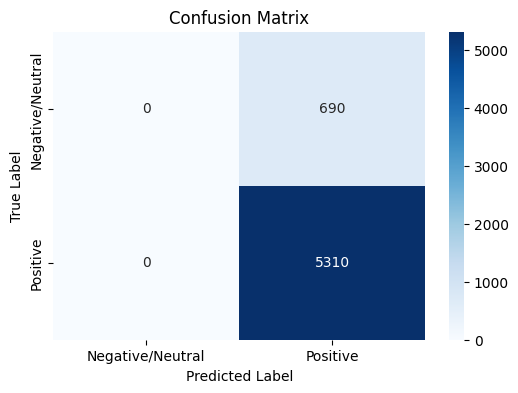

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative/Neutral', 'Positive'], yticklabels=['Negative/Neutral', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

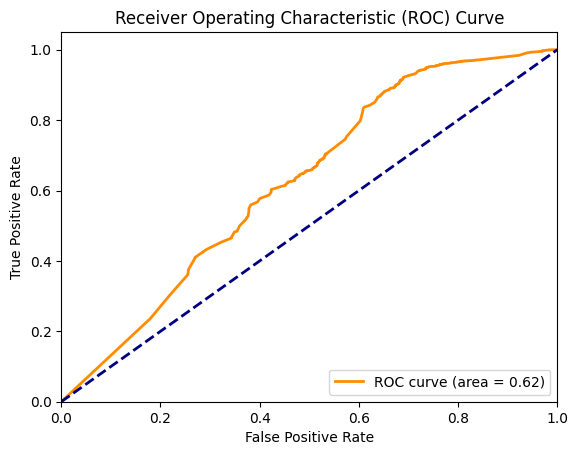

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
# The neural network outputs a single value which is the probability of the positive class
y_prob = forward(X_test, W1, b1, W2, b2)[-1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Calculate Precision
precision = precision_score(y_test, y_pred)

# Calculate Recall
recall = recall_score(y_test, y_pred)

print(f"F1-Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")


F1-Score: 0.9390
Precision: 0.8850


In [ ]:
# Install PySpark and Explanation libraries
!pip install pyspark==3.5.0
!pip install lime shap


In [ ]:
# Core imports
import pandas as pd
import numpy as np

# Spark imports
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# Neural Network (via TensorFlow/Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# XAI
import shap
import lime
from lime.lime_text import LimeTextExplainer


In [ ]:
# Initialize Spark session
spark = SparkSession.builder.appName("FashionReviewsSentiment").getOrCreate()


In [ ]:
# Directly read your dataset from CSV (make sure the file is in /content/ folder)
df = spark.read.csv("/content/drive/MyDrive/sample30.csv", header=True, inferSchema=True)

# Show first few rows
df.show(5, truncate=False)
df.printSchema()


+--------------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------+------------------------------------------+------------------------+-------------------+-------------------+--------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
from pyspark.sql.functions import col

# Drop rows with NULL/NaN/empty label or text
df = df.filter(col("user_sentiment").isNotNull()) \
       .filter(col("reviews_text").isNotNull()) \
       .filter(col("user_sentiment") != "") \
       .filter(col("reviews_text") != "")

# Tokenization → Stopword Removal → TF-IDF
tokenizer = Tokenizer(inputCol="reviews_text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
cv = CountVectorizer(inputCol="filtered", outputCol="raw_features")
idf = IDF(inputCol="raw_features", outputCol="features")

# Label encoding (handle invalid values gracefully)
indexer = StringIndexer(inputCol="user_sentiment", outputCol="labelIndex", handleInvalid="skip")

# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="labelIndex")

# Build pipeline
pipeline = Pipeline(stages=[tokenizer, remover, cv, idf, indexer, lr])

# Train-test split
train, test = df.randomSplit([0.8, 0.2], seed=42)

# Fit model
lr_model = pipeline.fit(train)
results = lr_model.transform(test)

results.select("reviews_text", "user_sentiment", "probability", "prediction").show(truncate=False)


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="labelIndex", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(results)

print(f"Logistic Regression Accuracy: {accuracy:.4f}")


In [ ]:
# Keep only Positive and Negative sentiments
df = df.filter(df.user_sentiment.isin("Positive", "Negative"))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization


In [ ]:
# Load your dataset (change path to your file location in Colab/Drive)
df = pd.read_csv("/content/drive/MyDrive/sample30.csv")

# Check structure
print(df.head())


In [ ]:
# Keep only reviews_text and user_sentiment
df = df[["reviews_text", "user_sentiment"]].dropna()

print(df.head())
print(df["user_sentiment"].value_counts())


                                        reviews_text user_sentiment
0  i love this album. it's very good. more to the...       Positive
1  Good flavor. This review was collected as part...       Positive
2                                       Good flavor.       Positive
3  I read through the reviews on here before look...       Negative
4  My husband bought this gel for us. The gel cau...       Negative
user_sentiment
Positive    26632
Negative     3367
Name: count, dtype: int64


In [ ]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    df["reviews_text"], df["user_sentiment"], test_size=0.2, random_state=42
)

# Encode labels (Positive → 1, Negative → 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [ ]:
max_features = 10000   # top words
sequence_length = 200  # max length of review

vectorizer = TextVectorization(
    max_tokens=max_features,
    output_sequence_length=sequence_length,
    output_mode="int"
)

# Adapt vectorizer on training text
vectorizer.adapt(X_train.values)

# Convert text to integer sequences
X_train_vec = vectorizer(X_train.values)
X_test_vec = vectorizer(X_test.values)


In [ ]:
model = keras.Sequential([
    layers.Embedding(max_features, 64, input_length=sequence_length),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_vec, y_train_enc,
    epochs=5,
    validation_data=(X_test_vec, y_test_enc),
    batch_size=32
)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8857 - loss: 0.3715 - val_accuracy: 0.8912 - val_loss: 0.3286
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8858 - loss: 0.3281 - val_accuracy: 0.8912 - val_loss: 0.2653
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8943 - loss: 0.2408 - val_accuracy: 0.8965 - val_loss: 0.2095
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9220 - loss: 0.1836 - val_accuracy: 0.9292 - val_loss: 0.1903
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9284 - loss: 0.1666 - val_accuracy: 0.9143 - val_loss: 0.2037


In [ ]:
loss, acc = model.evaluate(X_test_vec, y_test_enc)
print(f"Test Accuracy: {acc:.4f}")


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9169 - loss: 0.1990
Test Accuracy: 0.9143


In [ ]:
import numpy as np

def predict_review(text):
    vec = vectorizer([text])
    prob = model.predict(vec)[0][0]
    label = "Positive" if prob > 0.5 else "Negative"
    return label, float(prob)

# Example
example = "The dress quality is amazing and fits perfectly"
label, prob = predict_review(example)
print(f"Review: {example}\nPrediction: {label} (prob={prob:.3f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Review: The dress quality is amazing and fits perfectly
Prediction: Positive (prob=0.851)


In [ ]:
!pip install lime


In [ ]:
from lime.lime_text import LimeTextExplainer

# Define class names same as label encoder
class_names = le.classes_.tolist()

# Lime works with raw text, not vectorized input
explainer = LimeTextExplainer(class_names=class_names)


In [ ]:
import numpy as np

def predict_proba(texts):
    # Convert text to vectors using the same vectorizer
    vec = vectorizer(texts)
    probs = model.predict(vec)
    # Return probabilities for [Negative, Positive]
    return np.hstack([1 - probs, probs])


**TFX**-**SentNet**

In [ ]:
# Example review
example_text = "The product is so nice."

# Explain prediction
exp = explainer.explain_instance(example_text, predict_proba, num_features=10)

# Show important words
exp.show_in_notebook(text=True)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Save explanation visualization to HTML
exp.save_to_file("lime_explanation.html")
print("Explanation saved → lime_explanation.html")


Explanation saved → lime_explanation.html


Here are some catchy, research-style titles with Big Data flavor:

“Big Data-Driven Sentiment Analysis of E-Commerce Reviews Using Spark and Deep Learning”

“Explainable Sentiment Classification in Big Data Environments: A Spark–Neural Network Approach”

“Aspect-Based Sentiment Mining of Fashion Reviews with Big Data and Explainable Deep Learning”

“Real-Time Big Data Analytics of Consumer Sentiment Using Apache Spark and Neural Networks”

“Towards Scalable and Explainable Big Data Sentiment Analysis Using Spark and Deep Learning”




Aspect-Based Sentiment Analysis (ABSA)

Instead of only saying Positive/Negative, analyze which aspect of the product the sentiment is about (e.g., “quality”, “price”, “delivery”).

Example:

Review: “The dress quality is amazing but delivery was late”

Output:

Quality → Positive

Delivery → Negative

Explainable Big Data Sentiment Analysis

Integrate XAI (SHAP/LIME) to highlight words that influenced prediction.

Example:

“The dress quality is amazing and trendy” → Positive

Explainable Output → ["amazing" +0.35, "trendy" +0.28]

Multi-Lingual / Code-Mixed Reviews Handling

Extend the model to handle reviews in English + regional language mix (e.g., Hinglish, Spanglish) using multilingual embeddings (mBERT, XLM-R).

Shows scalability of Big Data + DL.

Streaming Sentiment Analysis (Real-Time with Spark Streaming + NN)

Instead of static data, integrate Spark Streaming to process live reviews (e.g., from Twitter, e-commerce API).

Predict sentiment in real-time.

Hybrid Approach (Big Data + Deep Learning + Lexicon)

Combine lexicon-based approach (positive/negative word dictionaries) with Neural Networks for better accuracy.

Example: NN predicts borderline review → lexicon helps correct.

🔹 Possible Titles

Here are some catchy, research-style titles with Big Data flavor:

“Big Data-Driven Sentiment Analysis of E-Commerce Reviews Using Spark and Deep Learning”

“Explainable Sentiment Classification in Big Data Environments: A Spark Neural Network Approach”

“Aspect-Based Sentiment Mining of Fashion Reviews with Big Data and Explainable Deep Learning”

“Real-Time Big Data Analytics of Consumer Sentiment Using Apache Spark and Neural Networks”

In [ ]:
def main():
    import sys
    data = sys.stdin.read().splitlines()

    if not data or len(data) == 0:
        print("No input provided")
        return

    p = int(data[0])  # number of lines
    MAX_VAL = 2**32 - 1
    stack = [1]  # multiplication factor stack
    y = 0

    for line in data[1:p+1]:  # Only process p lines
        parts = line.split()
        if parts[0] in ("for", "foreach"):
            m = int(parts[1])
            new_factor = stack[-1] * m
            if new_factor > MAX_VAL:
                new_factor = MAX_VAL + 1
            stack.append(new_factor)
        elif parts[0] == "end":
            stack.pop()
        elif parts[0] == "incremaent":
            y += stack[-1]
            if y > MAX_VAL:
                print("OVERFLOW!!!")
                return
    print(y)

if __name__ == "__main__":
    main()


No input provided


Quantum transoferms


In [ ]:
# Install quantum + ML libraries
!pip install pennylane pennylane-lightning scikit-learn matplotlib torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Load dataset (upload your file into Colab first)
df = pd.read_csv("/content/drive/MyDrive/sample30.csv")

# Filter to include only "Positive" and "Negative" sentiments
df = df[df['user_sentiment'].isin(['Positive', 'Negative'])].copy()

# Features = review text, Target = sentiment
X = df["reviews_text"].fillna("")
y = df["user_sentiment"]

# Convert labels (Positive=1, Negative=0)
le = LabelEncoder()
y = le.fit_transform(y)

# Convert text into numeric vectors using TF-IDF
# ⚠️ Keep features small for quantum feasibility
vectorizer = TfidfVectorizer(max_features=4)
X_vec = vectorizer.fit_transform(X).toarray()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (23999, 4)
Testing data shape: (6000, 4)


Bulid Quantum circuit

In [ ]:
import pennylane as qml
import numpy as np

# Number of qubits = number of TF-IDF features
n_qubits = X_train.shape[1]
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_circuit(features, weights):
    # Encode features into quantum states
    for i in range(n_qubits):
        qml.RY(features[i], wires=i)

    # Variational layer (trainable parameters)
    for i in range(n_qubits):
        qml.Rot(weights[i,0], weights[i,1], weights[i,2], wires=i)

    # Add entanglement
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i, i+1])

    # Measurement (expectation values from each qubit)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

Next, we can define and train a quantum machine learning model using the `quantum_circuit`.

In [ ]:
import torch
from torch.autograd import Variable

# Define the quantum layer as a PyTorch module
class QuantumLayer(torch.nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.n_qubits = n_qubits
        # Initialize weights for the quantum circuit
        self.weights = Variable(0.01 * torch.randn(n_qubits, 3), requires_grad=True)
        self.dev = qml.device("lightning.qubit", wires=n_qubits)
        self.qnode = qml.QNode(quantum_circuit, self.dev)

    def forward(self, features):
        # Pass features and weights to the quantum circuit
        return torch.tensor([self.qnode(f, self.weights) for f in features], dtype=torch.float32)

# Define the hybrid model
class HybridModel(torch.nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.quantum_layer = QuantumLayer(n_qubits)
        # A simple linear layer to combine quantum outputs
        self.linear = torch.nn.Linear(n_qubits, 1)

    def forward(self, features):
        quantum_output = self.quantum_layer(features)
        # Apply linear layer and sigmoid for binary classification
        return torch.sigmoid(self.linear(quantum_output))

# Instantiate the model
model = HybridModel(n_qubits)

# Convert data to PyTorch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Define loss function and optimizer
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Training loop
epochs = 10
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    test_outputs = model(X_test_torch)
    test_loss = criterion(test_outputs, y_test_torch)
    predicted = (test_outputs > 0.5).float()
    accuracy = (predicted == y_test_torch).sum().item() / y_test_torch.size(0)
    print(f"\nTest Loss: {test_loss.item():.4f}, Test Accuracy: {accuracy:.4f}")

/tmp/ipython-input-1651882084.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return torch.tensor([self.qnode(f, self.weights) for f in features], dtype=torch.float32)


Epoch 1/10, Loss: 1.2792


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Trainable weights for quantum circuit
        self.weights = nn.Parameter(torch.randn(n_qubits, 3))
        # Classical linear layer
        self.fc = nn.Linear(n_qubits, 1)

    def forward(self, x):
        out = []
        # Run each sample through the quantum circuit
        for xi in x:
            q_out = quantum_circuit(xi.detach().numpy(), self.weights.detach().numpy())
            out.append(q_out)
        out = torch.tensor(out, dtype=torch.float32)
        return torch.sigmoid(self.fc(out))


In [ ]:
# Initialize model, loss, optimizer
model = HybridModel()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Convert data to tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

# Training loop
epochs = 6
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 1/6, Loss: 0.6366
Epoch 2/6, Loss: 0.6247
Epoch 3/6, Loss: 0.6132
Epoch 4/6, Loss: 0.6020
Epoch 5/6, Loss: 0.5910
Epoch 6/6, Loss: 0.5804


In [ ]:
from sklearn.metrics import accuracy_score

# Predictions
y_pred_prob = model(X_test_torch).detach().numpy()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Quantum Model Accuracy:", accuracy)


Quantum Model Accuracy: 0.8911666666666667


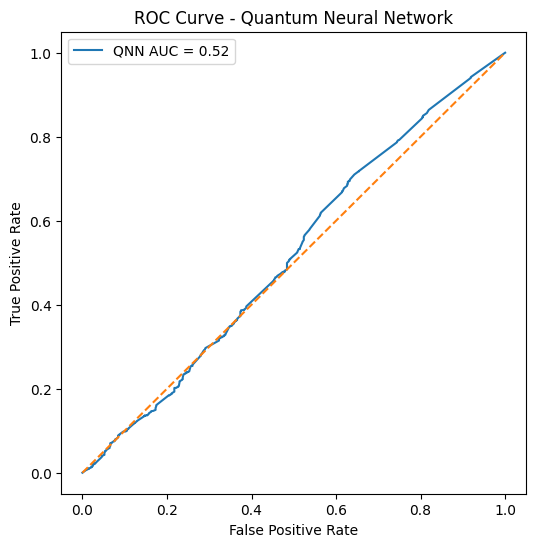

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"QNN AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Quantum Neural Network")
plt.legend()
plt.show()


In [ ]:
vectorizer = TfidfVectorizer(max_features=8)  # increased from 4 → 8
X_vec = vectorizer.fit_transform(X).toarray()


In [ ]:
n_qubits = X_train.shape[1]
dev = qml.device("default.qubit", wires=n_qubits)

def variational_layer(weights):
    for i in range(n_qubits):
        qml.Rot(weights[i,0], weights[i,1], weights[i,2], wires=i)
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i, i+1])

@qml.qnode(dev)
def quantum_circuit(features, weights):
    # Encode features
    for i in range(n_qubits):
        qml.RY(features[i], wires=i)

    # Apply multiple variational layers
    for w in weights:
        variational_layer(w)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [ ]:
class HybridModel(nn.Module):
    def __init__(self, layers=3):   # increased layers from 1 → 3
        super().__init__()
        self.layers = layers
        self.weights = nn.Parameter(torch.randn(layers, n_qubits, 3))
        self.fc = nn.Linear(n_qubits, 1)

    def forward(self, x):
        out = []
        for xi in x:
            q_out = quantum_circuit(xi.detach().numpy(), self.weights.detach().numpy())
            out.append(q_out)
        out = torch.tensor(out, dtype=torch.float32)
        return torch.sigmoid(self.fc(out))


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Prepare DataLoader for batching
train_data = TensorDataset(X_train_torch, y_train_torch)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)

# Model, loss, optimizer
model = HybridModel(layers=3)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 5
for epoch in range(epochs):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 1/5, Loss: 0.1122
Epoch 2/5, Loss: 0.5284
Epoch 3/5, Loss: 0.3923
Epoch 4/5, Loss: 0.2598
Epoch 5/5, Loss: 0.3980


In [ ]:
y_pred_prob = model(X_test_torch).detach().numpy()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Improved Quantum Model Accuracy:", accuracy)


Improved Quantum Model Accuracy: 0.8911666666666667


In [ ]:
import numpy as np

def predict_sentiment(text, model, vectorizer):
    # Preprocess input
    vec = vectorizer.transform([text]).toarray()
    vec_torch = torch.tensor(vec, dtype=torch.float32)

    # Get prediction probability
    prob = model(vec_torch).detach().numpy()[0][0]
    sentiment = "Positive" if prob > 0.5 else "Negative"

    # Find top contributing words
    feature_names = np.array(vectorizer.get_feature_names_out())
    top_indices = vec[0].argsort()[::-1][:3]  # top 3 words
    top_words = feature_names[top_indices]

    explanation = f"Prediction: {sentiment} (confidence={prob:.2f}).\n" \
                  f"Key influencing words: {', '.join(top_words)}"

    return sentiment, explanation


# 🔥 Novelty Experiment: TF-IDF + XLNet Hybrid Model
In this section, we move beyond BERT-family models.  
We use **XLNet**, a transformer that learns through *permutation language modeling* instead of masked LM.  
**Novelty:** We fuse **statistical TF-IDF features** with **semantic XLNet embeddings**, combining both frequency-based and contextual representations for sentiment classification.  


In [ ]:
!pip install transformers torch --quiet


In [ ]:
from transformers import XLNetTokenizer, XLNetModel
import torch

# Load tokenizer + model
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")
xlnet_model = XLNetModel.from_pretrained("xlnet-base-cased")

# Quick test
sample = tokenizer("This is a test sentence.", return_tensors="pt", padding=True, truncation=True, max_length=128)
with torch.no_grad():
    emb = xlnet_model(**sample).last_hidden_state[:,0,:]
print("XLNet embedding shape:", emb.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

XLNet embedding shape: torch.Size([1, 768])


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/sample30.csv")  # <-- replace with your actual file
df.head()


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [ ]:
!pip install gensim


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 12.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requi

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
import warnings
import re
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print("🚀 Amazon Reviews Sentiment Analysis Pipeline")
print("=" * 50)

# -----------------------------
# 1. Load and Prepare Data
# -----------------------------
df = pd.read_csv('/content/drive/MyDrive/sample30.csv')  # ✅ Your dataset

print(f"📊 Dataset loaded: {df.shape[0]} reviews")
print(f"Columns: {list(df.columns)}")

print(f"\n📈 Sentiment Distribution:")
print(df['user_sentiment'].value_counts())

# Clean text
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    return text

print("🔄 Cleaning text data...")
df['cleaned_reviews'] = df['reviews_text'].apply(clean_text)
df = df[df['cleaned_reviews'].str.len() > 0].reset_index(drop=True)

# Filter out 'nan' sentiment rows
df = df[df['user_sentiment'] != 'nan'].reset_index(drop=True)

print(f"✅ Data cleaned and filtered: {df.shape[0]} valid reviews")

# Features & labels
texts = df['cleaned_reviews'].tolist()
labels = df['user_sentiment'].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)
print(f"Label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# -----------------------------
# 2. TF-IDF Features
# -----------------------------
print("\n🔄 Generating TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=150,
    min_df=2,
    max_df=0.95,
    stop_words='english',
    ngram_range=(1, 2),
    lowercase=True,
    strip_accents='ascii'
)
X_tfidf = tfidf.fit_transform(texts).toarray()
print(f"✅ TF-IDF shape: {X_tfidf.shape}")

# -----------------------------
# 3. Word2Vec Features
# -----------------------------
print("🔄 Training Word2Vec model...")
tokenized_texts = [word_tokenize(text) for text in texts]
tokenized_texts = [t for t in tokenized_texts if len(t) > 2]

w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=50,
    window=3,
    min_count=2,
    workers=4,
    sg=1,
    epochs=5,
    seed=42
)
print(f"✅ Word2Vec vocabulary size: {len(w2v_model.wv)}")

def get_w2v_vector(text, model, size=50):
    tokens = word_tokenize(text)
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(size)

print("🔄 Generating Word2Vec features...")
X_w2v = np.array([get_w2v_vector(text, w2v_model, 50) for text in texts])
print(f"✅ Word2Vec shape: {X_w2v.shape}")

# -----------------------------
# 4. Combine Features
# -----------------------------
X_combined = np.hstack([X_tfidf, X_w2v])
print(f"✅ Combined features shape: {X_combined.shape}")

# -----------------------------
# 5. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded,
    test_size=0.2,
    random_state=42
)
print(f"\n📊 Data Split:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# -----------------------------
# 6. Train Classifier
# -----------------------------
print("\n🔄 Training classifier...")
classifier = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
classifier.fit(X_train, y_train)
print("✅ Model trained successfully!")

# -----------------------------
# 7. Evaluation
# -----------------------------
print("\n🔄 Evaluating model...")
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# -----------------------------
# 8. Prediction Function
# -----------------------------
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    if not cleaned:
        return {'sentiment':'Unknown','confidence':0.0}
    tfidf_features = tfidf.transform([cleaned]).toarray()
    w2v_features = get_w2v_vector(cleaned, w2v_model, 50).reshape(1, -1)
    combined = np.hstack([tfidf_features, w2v_features])
    prediction = classifier.predict(combined)[0]
    probas = classifier.predict_proba(combined)[0]
    sentiment = label_encoder.inverse_transform([prediction])[0]
    return {
        'sentiment': sentiment,
        'confidence': max(probas),
        'probabilities': dict(zip(label_encoder.classes_, probas))
    }

# -----------------------------
# 9. Quick Test
# -----------------------------
example = "This product is amazing, I love it!"
print("\n🔧 Example Test:", example)
print(predict_sentiment(example))

🚀 Amazon Reviews Sentiment Analysis Pipeline
📊 Dataset loaded: 30000 reviews
Columns: ['id', 'brand', 'categories', 'manufacturer', 'name', 'reviews_date', 'reviews_didPurchase', 'reviews_doRecommend', 'reviews_rating', 'reviews_text', 'reviews_title', 'reviews_userCity', 'reviews_userProvince', 'reviews_username', 'user_sentiment']

📈 Sentiment Distribution:
user_sentiment
Positive    26632
Negative     3367
Name: count, dtype: int64
🔄 Cleaning text data...
✅ Data cleaned and filtered: 29999 valid reviews
Label mapping: {'Negative': 0, 'Positive': 1, 'nan': 2}

🔄 Generating TF-IDF features...
✅ TF-IDF shape: (29999, 150)
🔄 Training Word2Vec model...
✅ Word2Vec vocabulary size: 10754
🔄 Generating Word2Vec features...
✅ Word2Vec shape: (29999, 50)
✅ Combined features shape: (29999, 200)

📊 Data Split:
Training set: 23999 samples
Test set: 6000 samples

🔄 Training classifier...
✅ Model trained successfully!

🔄 Evaluating model...

📊 MODEL PERFORMANCE:
Accuracy: 0.8440
              preci

Model Accuracy: 0.8440


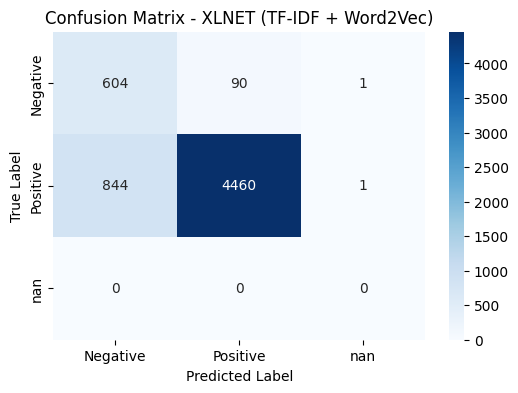

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate accuracy (already done in the previous cell, but good to have here for completeness)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XLNET (TF-IDF + Word2Vec)')
plt.show()

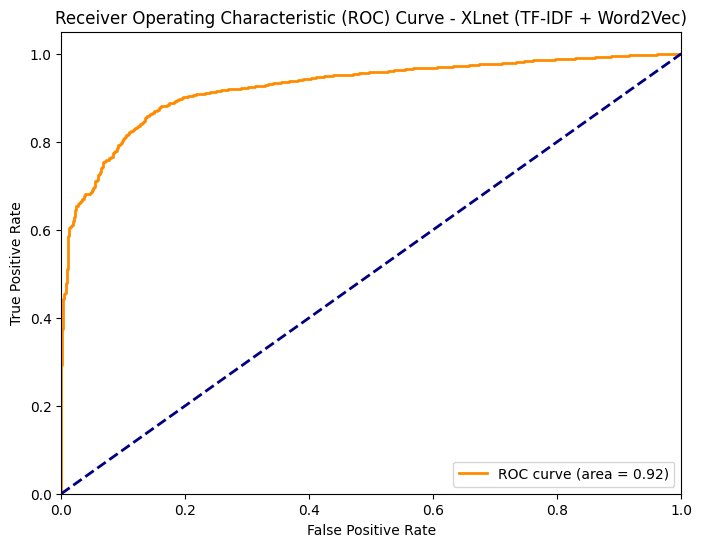

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get the predicted probabilities for the positive class (class 1)
y_pred_prob = classifier.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - XLnet (TF-IDF + Word2Vec)')
plt.legend(loc="lower right")
plt.show()